In [1]:
import sqlite3
from typing import Union
from tqdm import tqdm
import pandas as pd
import pdfplumber
from openai import OpenAI
import json
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [2]:
# Define the path to your db_schema.pdf file
# Ensure 'db_schema.pdf' is in the same directory as your script,
# or provide the full path to the file.
pdf_path = "../assignment/db_schema.pdf"

db_schema_desc = ""
try:
    with pdfplumber.open(pdf_path) as pdf:
        # Iterate through each page of the PDF
        for page in pdf.pages:
            # Extract text from the current page
            page_text = page.extract_text()
            if page_text: # Ensure text was extracted
                # Add extracted text and a clear separator for clarity between pages
                db_schema_desc += page_text
    print(db_schema_desc)
except FileNotFoundError:
    print(f"Error: The file '{pdf_path}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An unexpected error occurred during PDF extraction: {e}")

The relational database moviedb has the following database schema:
Movie(title, production year, country, run time, major genre)
primary key : {title, production year}
Person(id, first name, last name, year born)
primary key : {id}
Award(award name, institution, country)
primary key : {award name}
Restriction Category(description, country)
primary key : {description, country}
Director(id, title, production year)
primary key : {title, production year}
foreign keys : [title, production year] ⊆ Movie[title, production year]
[id] ⊆ Person[id]
Writer(id, title, production year, credits)
primary key : {id, title, production year}
foreign keys : [title, production year] ⊆ Movie[title, production year]
[id] ⊆ Person[id]
Crew(id, title, production year, contribution)
primary key : {id, title, production year}
foreign keys : [title, production year] ⊆ Movie[title, production year]
[id] ⊆ Person[id]
Scene(title, production year, scene no, description)
primary key : {title, production year, scene 

In [3]:

# 1. Define the path to your SQLite database file
# Make sure 'Submission.sqlite' is in the same directory as your Python script,
# or provide the full path to the file.
db_file = '../assignment/Submission.sqlite'

MAX_ROWS_PER_GROUP = 100

try:
    # 2. Connect to the SQLite database
    # This creates a connection object. If the database file doesn't exist,
    # it will be created (though for this dataset, it should already exist).
    conn = sqlite3.connect(db_file)
    print(f"Successfully connected to {db_file}")

    # 3. Create a cursor object
    # A cursor allows you to execute SQL commands.
    cursor = conn.cursor()

    # 4. Define the columns you want to select from the 'exercises_result' table
    # Based on the dataset description, available columns include:
    # submission_id, submitted_answer, submission_time, exercise_id,
    # is_correct, student_id, category [1]
    columns_to_select = [
        "preamble",
        "submitted_answer",
        "category",
        "difficulty",
    ]

    # 5. Construct the SQL SELECT query
    # The table containing student submissions is named 'exercises_result'.[1]
    query = f"""
        WITH RankedExercises AS (
          SELECT
            {', '.join(columns_to_select)},
            ROW_NUMBER() OVER (PARTITION BY T1.category ORDER BY RANDOM()) AS rn
          FROM exercises_result AS T1
          JOIN exercises_exercise AS T2
            ON T1.exercise_id = T2.id
        )
        SELECT
          {', '.join(columns_to_select)}
        FROM RankedExercises
        WHERE
          rn <= {MAX_ROWS_PER_GROUP};
    """

    print(f"\nExecuting query: {query}")

    # 6. Execute the query
    cursor.execute(query)

    # 7. Fetch the results
    # fetchall() retrieves all rows from the last executed statement.
    rows = cursor.fetchall()

    # 8. Get column names from the cursor description (optional, but good for context)
    column_names = [description[0] for description in cursor.description]

    # 9. Process and display the results
    if rows:
        print(f"\nFetched {len(rows)} rows. Displaying first 5 rows:")
        # Using pandas for a cleaner display of tabular data
        df = pd.DataFrame(rows, columns=column_names)
        df['category_pred'] = None

        labels_to_ids = {label: idx for idx, label in enumerate(df["category"].unique())}
        total_limit = len(labels_to_ids) * 100
        print(labels_to_ids)
        print(df.head())

        difficulties = sorted(df['difficulty'].unique())
        print(f"Difficulties: {difficulties}")
    else:
        print("No data found in the 'exercises_result' table with the specified columns.")

except sqlite3.Error as e:
    print(f"An SQLite error occurred: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
finally:
    # 10. Close the connection
    # It's good practice to close the connection when you're done.
    if 'conn' in locals() and conn:
        conn.close()
        print(f"\nConnection to {db_file} closed.")

Successfully connected to Submission.sqlite

Executing query: 
        WITH RankedExercises AS (
          SELECT
            preamble, submitted_answer, category, difficulty,
            ROW_NUMBER() OVER (PARTITION BY T1.category ORDER BY RANDOM()) AS rn
          FROM exercises_result AS T1
          JOIN exercises_exercise AS T2
            ON T1.exercise_id = T2.id
        )
        SELECT
          preamble, submitted_answer, category, difficulty
        FROM RankedExercises
        WHERE
          rn <= 100;
    

Fetched 313 rows. Displaying first 5 rows:
{'cheating': 0, 'correct': 1, 'noninterpretable': 2, 'partially correct': 3}
                                            preamble  \
0  Consider the given relational database moviedb...   
1  Consider the given relational database moviedb...   
2  Consider the given relational database moviedb...   
3  Consider the given relational database moviedb...   
4  Consider the given relational database moviedb...   

                

In [4]:
# --- Configuration for LM Studio's OpenAI-compatible API ---
# The default base URL for LM Studio's local server is http://localhost:1234/v1.
# Ensure your LM Studio server is running and listening on this port.
# The '/v1' path is crucial for OpenAI compatibility.
LM_STUDIO_BASE_URL = "http://localhost:1234/v1"

# For local LM Studio deployments, the API key is a placeholder.
# Use "lm-studio" as specified in the LM Studio documentation.
LM_STUDIO_API_KEY = "lm-studio"

# Replace with the actual identifier of the model you have downloaded and loaded in LM Studio.
# You can find this model identifier in the LM Studio UI once a model is loaded.

# Tested models: qwen/qwen2.5-coder-14b, mistralai/codestral-22b-v0.1, ibm/granite-3.1-8b
LM_STUDIO_MODEL_NAME = "google/gemma-3-12b"

# --- Initialize the OpenAI client ---
# We point the client to our local LM Studio server.
client = OpenAI(
    base_url=LM_STUDIO_BASE_URL,
    api_key=LM_STUDIO_API_KEY
)

def ask_lm_studio(question: str) -> Union[dict, None]:
    try:
        # Send the chat completion request.
        # The 'messages' parameter takes a list of dictionaries,
        # where each dictionary represents a role (system, user, assistant) and content.
        completion = client.chat.completions.create(
            model=LM_STUDIO_MODEL_NAME,
            messages=[
                {"role": "system", "content": """As an expert SQL instructor, you play a key role in automatically grading student SQL statements. Your primary goal is to provide students with comprehensive, diagnostic and pedagogically valuable feedback to help them learn and improve, rather than simply marking their work as pass or fail. You must output a JSON object with the following structure and content:
                {
                  "category": "<noninterpretable|partially correct|correct|cheating>",
                  "feedback": {
                    "summary": "<brief_summary_of_grade_and_main_issue>",
                    "detailed_explanation": "<comprehensive_explanation_of_errors_or_correctness>",
                    "specific_errors": [
                      {
                        "description": "<detailed_description_of_this_specific_error>",
                        "suggestion": "<actionable_advice_for_improvement>"
                      }
                    ],
                    "improvement_suggestions": "<overall_advice_for_student_to_improve_their_SQL_skills>"
                  }
                }
                The category field should be one of the following:
                    1. "noninterpretable": the statement is non-executable. Here are some examples of which you should classify as noninterpretable:
                    Question: How many writers were born in 1935? Answer: SELECT SUM(first_name) FROM person WHERE year_born == 1935; The correct answer is: SELECT count(*) FROM person p WHERE EXISTS (SELECT * FROM writer w WHERE w.id = p.id AND p.year_born = 1935);
                    Question: How many writers were born in 1935? Answer: SELECT COUNT(id) FROM PERSON WHERE year_born == 1935; The correct answer is: SELECT count(*) FROM person p WHERE EXISTS (SELECT * FROM writer w WHERE w.id = p.id AND p.year_born = 1935);
                    Question: How many writers were born in 1935? Answer: select count(*) The correct answer is: SELECT count(*) FROM person p WHERE EXISTS (SELECT * FROM writer w WHERE w.id = p.id AND p.year_born = 1935);
                    Question: How many writers were born in 1935? Answer: SELECT COUNT(*) from WRITER where WRITER.id=PERSON.id AND PERSON.year_born=1935; The correct answer is: SELECT count(*) FROM person p WHERE EXISTS (SELECT * FROM writer w WHERE w.id = p.id AND p.year_born = 1935);
                    Question: Which movies were written by Kevin Williamson? List the titles and production years of these movies. Answer: select m.title, m.production_year from (movie natural join writer natural join person) as m where m.first_name=Kevin and m.last_name=Williamson group by m.title;
                    The correct answer is: SELECT w.title, w.production_year FROM writer w, person p WHERE w.id = p.id AND lower(first_name)= 'kevin' AND lower(last_name)= 'williamson';
                    Question: Who have been nominated for a director award at least once, but have never won any director award? List their ids, and the award names, years of awards and categories which they have been nominated for. Answer: select d.id, d.award_name, d.year_of_award, d.category from (Director_Award natural join person) as d where lower(d.result)= 'nominated' and not exists lower(d.result)='won'; The correct answer is: SELECT d.id, da.award_name, da.year_of_award, da.category FROM director_award da, director d WHERE da.title = d.title AND da.production_year = d.production_year AND lower(da.result)= 'nominated' AND d.id NOT IN (SELECT id FROM director_award da, director d WHERE da.title = d.title AND da.production_year = d.production_year AND lower(da.result)= 'won' );
                    Question: Who have directed at least two movies that were written by themselves (i.e., a director is one of the writers for the same movie)? Show their ids, the ﬁrst and last names Answer: select id, first_name, last_name from person, (select count(*)as c from director, writer where director.id = writer.id and director.id = person.id) as test where test.c>1; The correct answer is: SELECT dw.id, dw.first_name, dw.last_name FROM (person p NATURAL JOIN director NATURAL JOIN writer) AS dw GROUP BY dw.id HAVING count(*) > 1;
                    Question: How many movies were produced in 1993, 1992 and 1991? List the production years and the corresponding numbers of movies. Answer: select count(*), production_year from movie having production_year= '1993'AND '1992' AND '1991' group by production_year; The correct answer is: SELECT production_year, count(*) FROM movie WHERE production_year > 1990 AND production_year < 1994 GROUP BY production_year;
                    Question: Which countries have restricted the movie ‘Shakespeare in Love’ as ‘M’? List the names of these countries. Answer: select mr.country from (movie m natural join restriction_category natural join restriction) as mr where mr.title = 'Shakespeare in Love' and mr.descripton = 'M'; The correct answer is: SELECT country FROM restriction WHERE lower(title) = 'shakespeare in love' AND description = 'M';
                    Question: List the titles and production years of all movies that have won a \"BAFTA Film Award\" under the category ‘Best Film’, together with the ﬁrst names and last names of their directors. Answer: (select m.title, m.production_year from movie_award m where m.award_name = 'BAFTA Film Award' and m.category = 'Best Film') UNION (select p.first_name, p.last_name from person p where director id = p.id); The correct answer is: SELECT ma.title, ma.production_year, p.first_name, p.last_name FROM (SELECT title, production_year FROM movie_award WHERE lower(award_name)= 'bafta film award' AND lower(category)= 'best film' AND lower(RESULT)= 'won' ) AS ma, director AS d, person AS p WHERE ma.title = d.title AND ma.production_year = d.production_year AND d.id = p.id;
                    2. "partially correct": the execution result of statement is different from the expected result. Here are some examples of which you should classify as partially correct:
                    Question: How many writers were born in 1935? Answer: SELECT COUNT(id) from PERSON where year_born = 1935; The correct answer is: SELECT count(*) FROM person p WHERE EXISTS (SELECT * FROM writer w WHERE w.id = p.id AND p.year_born = 1935);
                    Question: Who is the youngest person in the database? List the id, ﬁrst name, and last name of this person. Answer: Select id From Person Order By year_born ASC Limit 1 Offset 1; The correct answer is: SELECT id, first_name, last_name FROM person p WHERE p.year_born = (SELECT max(year_born) FROM person);
                    Question: Who appeared in exactly one scene in the movie ‘Psycho’ produced in 1960? List ids of these actors/actresses. Answer: SELECT person.id FROM movie, role, appearance, person WHERE movie.title = role.title = appearance.title AND movie.production_year = role.production_year = appearance.production_year AND role.id = person.id AND movie.title = 'Psycho' AND movie.production_year = 1960 GROUP BY person.id HAVING COUNT(DISTINCT appearance.scene_no) = 1; This is correct answer: SELECT r.id FROM scene s, appearance a, ROLE r WHERE s.title = a.title AND s.production_year = a.production_year AND s.scene_no = a.scene_no AND s.title = r.title AND s.production_year = r.production_year AND a.description = r.description AND lower(a.title) = 'psycho' AND a.production_year = 1960 GROUP BY r.id HAVING count(*) = 1;
                    Question: How many movies have never won any award, i.e., received none of movie awards, crew awards, director awards, writer awards and actor awards? List the total number of such movies stored in the database. Answer: SELECT title, production_year FROM movie EXCEPT SELECT title, production_year FROM movie_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM crew_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM director_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM writer_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM actor_award WHERE LOWER(result)='won'; The correct answer is: SELECT count(*) FROM movie m WHERE not exists (SELECT title, production_year FROM movie_award ma WHERE lower(ma.result) = 'won' and ma.title = m.title and ma.production_year = m.production_year UNION SELECT title, production_year FROM crew_award ca WHERE lower(ca.result) = 'won' and ca.title = m.title and ca.production_year = m.production_year UNION SELECT title, production_year FROM director_award da WHERE lower(da.result) = 'won' and da.title = m.title and da.production_year = m.production_year UNION SELECT title, production_year FROM actor_award aa WHERE lower(aa.result) = 'won' and aa.title = m.title and aa.production_year = m.production_year UNION SELECT title, production_year FROM writer_award wa WHERE lower(wa.result) = 'won' and wa.title = m.title and wa.production_year = m.production_year);
                    Question: Who appeared in exactly one scene in the movie ‘Psycho’ produced in 1960? List ids of these actors/actresses. Answer: select id from role r where exists( select * from scene s, appearance a where s.title='Psycho' and s.production_year='1960' and r.title=s.title and r.title=a.title and r.production_year=s.production_year and s.production_year=a.production_year AND s.scene_no = a.scene_no) group by r.id having count(*)=1; The correct answer is: SELECT r.id FROM scene s, appearance a, ROLE r WHERE s.title = a.title AND s.production_year = a.production_year AND s.scene_no = a.scene_no AND s.title = r.title AND s.production_year = r.production_year AND a.description = r.description AND lower(a.title) = 'psycho' AND a.production_year = 1960 GROUP BY r.id HAVING count(*) = 1;
                    Question: How many movies have never won any award, i.e., received none of movie awards, crew awards, director awards, writer awards and actor awards? List the total number of such movies stored in the database. Answer: select count(*) from movie m where not exists( select * from (movie_award ma natural join crew_award ca natural join director_award da natural join writer_award wa natural join actor_award aa) as abc where abc.result='won' and m.title=abc.title and abc.production_year=m.production_year); The correct answer is: SELECT count(*) FROM movie m WHERE not exists (SELECT title, production_year FROM movie_award ma WHERE lower(ma.result) = 'won' and ma.title = m.title and ma.production_year = m.production_year UNION SELECT title, production_year FROM crew_award ca WHERE lower(ca.result) = 'won' and ca.title = m.title and ca.production_year = m.production_year UNION SELECT title, production_year FROM director_award da WHERE lower(da.result) = 'won' and da.title = m.title and da.production_year = m.production_year UNION SELECT title, production_year FROM actor_award aa WHERE lower(aa.result) = 'won' and aa.title = m.title and aa.production_year = m.production_year UNION SELECT title, production_year FROM writer_award wa WHERE lower(wa.result) = 'won' and wa.title = m.title and wa.production_year = m.production_year);
                    3. "correct": the execution result of the SQL statement is the same as the expected result. Here are some examples of which you should classify as correct:
                    Question: How many movies have never won any award, i.e., received none of movie awards, crew awards, director awards, writer awards and actor awards? List the total number of such movies stored in the database. Answer: SELECT COUNT(*) FROM (SELECT title, production_year FROM movie EXCEPT SELECT title, production_year FROM movie_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM crew_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM director_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM writer_award WHERE LOWER(result)='won' EXCEPT SELECT title, production_year FROM actor_award WHERE LOWER(result)='won'); The correct answer is: SELECT count(*) FROM movie m WHERE not exists (SELECT title, production_year FROM movie_award ma WHERE lower(ma.result) = 'won' and ma.title = m.title and ma.production_year = m.production_year UNION SELECT title, production_year FROM crew_award ca WHERE lower(ca.result) = 'won' and ca.title = m.title and ca.production_year = m.production_year UNION SELECT title, production_year FROM director_award da WHERE lower(da.result) = 'won' and da.title = m.title and da.production_year = m.production_year UNION SELECT title, production_year FROM actor_award aa WHERE lower(aa.result) = 'won' and aa.title = m.title and aa.production_year = m.production_year UNION SELECT title, production_year FROM writer_award wa WHERE lower(wa.result) = 'won' and wa.title = m.title and wa.production_year = m.production_year);
                    Question: Who have directed at least two movies that were written by themselves (i.e., a director is one of the writers for the same movie)? Show their ids, the ﬁrst and last names Answer: select p.id, p.first_name, p.last_name from person p where p.id in (select t1.id from (select t.id, count(*) as Number from (select id from director natural join writer) t group by t.id) t1 where t1.Number>1); The correct answer is: SELECT dw.id, dw.first_name, dw.last_name FROM (person p NATURAL JOIN director NATURAL JOIN writer) AS dw GROUP BY dw.id HAVING count(*) > 1;
                    Question: List the titles and production years of all movies that have won a "BAFTA Film Award" under the category ‘Best Film’, together with the ﬁrst names and last names of their directors. Answer: SELECT title, production_year, first_name, last_name FROM (movie_award NATURAL JOIN director NATURAL JOIN person) WHERE LOWER(award_name)='bafta film award' AND LOWER(category)='best film' AND LOWER(result)='won'; The correct answer is: SELECT ma.title, ma.production_year, p.first_name, p.last_name FROM (SELECT title, production_year FROM movie_award WHERE lower(award_name)= 'bafta film award' AND lower(category)= 'best film' AND lower(RESULT)= 'won' ) AS ma, director AS d, person AS p WHERE ma.title = d.title AND ma.production_year = d.production_year AND d.id = p.id;
                    Question: Assume persons who were born in the same year are the same age and there is only one youngest person (with no ties/draws) in this database, who is/are the second youngest person(s) in the database? List the id(s) of the person(s). Answer: SELECT id FROM person WHERE year_born = (SELECT MAX(year_born) FROM (SELECT id, year_born FROM person WHERE year_born!=(SELECT MAX(year_born) FROM person)) AS t1); The correct answer is: SELECT p.id FROM person p WHERE p.year_born = (SELECT MAX(year_born) FROM person WHERE year_born < (SELECT MAX(year_born) FROM person));
                    Question: Who have directed at least two movies that were written by themselves (i.e., a director is one of the writers for the same movie)? Show their ids, the ﬁrst and last names Answer: select d.id, p.first_name,p.last_name from director d natural join writer w natural join person p where d.id=w.id group by d.id having count(*)>=2; The correct answer is: SELECT dw.id, dw.first_name, dw.last_name FROM (person p NATURAL JOIN director NATURAL JOIN writer) AS dw GROUP BY dw.id HAVING count(*) > 1;
                    Question: How many writer awards have been given to Woody Allen between 1991 and 1995 (inclusive)? List the number of the awards. Answer: select count(*) from writer w natural join person p natural join writer_award a where first_name = 'Woody' and last_name = 'Allen' and year_of_award>='1991' and year_of_award<=1995 and result ='won'; The correct answer is: SELECT COUNT(*) AS number_of_award FROM writer_award wa, writer w, person p WHERE wa.title = w.title AND wa.production_year = w.production_year AND wa.id = w.id AND w.id = p.id AND lower(RESULT)= 'won' AND lower(first_name)= 'woody' AND lower(last_name)= 'allen' AND year_of_award >= 1991 AND year_of_award <= 1995;
                    Question: How many persons have never directed any movies in this database? List the total number of such persons. Answer: select count (*) from person p where p.id not in(select p.id from director d natural join movie natural join person p); The correct answer is: SELECT count(*) FROM person p WHERE NOT EXISTS (SELECT * FROM director d WHERE p.id = d.id);
                    Question: How many persons have never directed any movies in this database? List the total number of such persons. Answer: select count(*) from person where person.id NOT in (select d.id from director as d); The correct answer is: SELECT count(*) FROM person p WHERE NOT EXISTS (SELECT * FROM director d WHERE p.id = d.id);
                    4. "cheating": the execution result of the above code was correct, but it was obviously not what the tutor expected. Here are some examples of which you should classify as cheating:
                    Question: Assume persons who were born in the same year are the same age and there is only one youngest person (with no ties/draws) in this database, who is/are the second youngest person(s) in the database? List the id(s) of the person(s). Answer: select id from person where id ='00000842'; The correct answer is: SELECT p.id FROM person p WHERE p.year_born = (SELECT MAX(year_born) FROM person WHERE year_born < (SELECT MAX(year_born) FROM person));
                    Do not output any other category than the above four in JSON: noninterpretable, partially correct, correct or cheating. Do not include any other categories besides the above four, such as 'incorrect' or 'wrong'!!!
                    Question: How many writers were born in 1935? Answer: select count(distinct 1935)from writer; The correct answer is: SELECT count(*) FROM person p WHERE EXISTS (SELECT * FROM writer w WHERE w.id = p.id AND p.year_born = 1935);
                """},
                {"role": "user", "content": question}
            ],
            temperature=0.9,  # Controls creativity (0.0 is deterministic, 1.0 is very creative)
            max_tokens=500    # Maximum number of tokens (words/parts of words) in the response
        )

        # Extract the content from the LLM's response.
        # The response structure is similar to OpenAI's API.
        if completion.choices and completion.choices[0].message:
            response = completion.choices[0].message.content
            print("Response: ", response)
            response = response.replace("```json", "").replace("```", "")
            y = json.loads(response)
            return y
        else:
            return None
    except Exception as e:
       print(f"An error occurred while communicating with LM Studio: {e}")
       return None

print("Attempting to connect to LM Studio...")

Attempting to connect to LM Studio...


In [5]:
for index, row in tqdm(df.iterrows(), total=400):
    user_query = f"""
        {row['preamble'].replace('<a href="https://cs.anu.edu.au/dab/bench/static/sql_doc/moviedb_schema.pdf" target="_blank">', '').replace("</a>", f": {db_schema_desc}")}
        Student's answer: {row['submitted_answer']}
    """
    print("Query: ", user_query)
    print("True Category: ", row['category'])

    # Send the query to LM Studio and get the response
    response = ask_lm_studio(user_query)

    df.loc[index, 'category_pred'] = response['category'] if response else None

  0%|          | 0/400 [00:00<?, ?it/s]

Query:  
        Consider the given relational database moviedb with this database schema: The relational database moviedb has the following database schema:
Movie(title, production year, country, run time, major genre)
primary key : {title, production year}
Person(id, first name, last name, year born)
primary key : {id}
Award(award name, institution, country)
primary key : {award name}
Restriction Category(description, country)
primary key : {description, country}
Director(id, title, production year)
primary key : {title, production year}
foreign keys : [title, production year] ⊆ Movie[title, production year]
[id] ⊆ Person[id]
Writer(id, title, production year, credits)
primary key : {id, title, production year}
foreign keys : [title, production year] ⊆ Movie[title, production year]
[id] ⊆ Person[id]
Crew(id, title, production year, contribution)
primary key : {id, title, production year}
foreign keys : [title, production year] ⊆ Movie[title, production year]
[id] ⊆ Person[id]
Scene(t

  0%|          | 1/400 [01:24<9:23:35, 84.75s/it]

Response:  ```json
{
  "category": "partially correct",
  "feedback": {
    "summary": "The query attempts to find a person born in 1992, but it's not guaranteed to be the youngest. It uses GROUP BY and HAVING which is unnecessary. The desired output requires selecting from person table.",
    "detailed_explanation": "The student's query focuses on finding a person born in 1992, which is potentially useful but not a complete solution. The student’s query grouped by id and then applied filter on year_born, which will return only one person if anyone was born in 1992. The core problem is the query doesn't actually determine the *youngest* person; it finds a person born in 1992 if such exists. The result would only correspond to the correct answer under specific circumstance; it is only partially correct",
    "specific_errors": [
      {
        "description": "The query groups by `id` unnecessarily which is not needed to get the youngest person." ,
        "suggestion": "Remove the `GRO

  0%|          | 2/400 [02:36<8:31:11, 77.06s/it]

...

Response:  ```json
{
  "category": "partially correct",
  "feedback": {
    "summary": "The query attempts to find the second youngest person, but it is flawed in its logic and results in an incorrect outcome. The query seems to misunderstand the objective, resulting in a wrong answer.",
    "detailed_explanation": "The student's query aims to identify the second youngest person by first finding the maximum year of birth and then relating it back to a potentially incorrect join. The logic behind using `max(year_born)` and relating it back to the overall query is not aligned with finding the second youngest person. The goal is to select all of those people whose year_born value excludes both the maximum and second-maximum values of year_born. The query, as it stands, will likely return something incorrect. To correctly find the second youngest person (or people) in the database, it's essential to first get either the highest and second highest year of birth or use a limit clause after o

 78%|███████▊  | 312/400 [6:19:16<1:50:24, 75.28s/it]

Response:  ```json
{
  "category": "partially correct",
  "feedback": {
    "summary": "The query attempts to list the required information but contains logical errors, resulting in inaccurate results. The join conditions are not explicitly stated and rely on implicit natural joins which can be unreliable. Further, the query doesn's directly link to movie award records.",
    "detailed_explanation": "The provided SQL query aims to retrieve the titles and production years of movies that have won a 'BAFTA Film Award' under the category 'Best Film', along with the first and last names of their directors. However, the query relies heavily on implicit joins (natural joins), which can lead to unexpected results due to ambiguity in the schema. The query also doesn't properly join movie awards, directors, and person tables to correctly display the expected results. To achieve this efficiently and accurately, it is best to use explicit joins.",
    "specific_errors": [
      {
        "descript

 78%|███████▊  | 313/400 [6:20:23<1:45:43, 72.92s/it]

Response:  ```json
{
  "category": "partially correct",
  "feedback": {
    "summary": "The query identifies directors who have also written at least two movies, but the output is only the id. The question asks for ids, first names and last names.",
    "detailed_explanation": "The student's query correctly identifies the ids of the directors who are also writers and have directed/written at least two movies. However, the question specifically requests the IDs, first names and last names of these people. The provided query only returns the ID which is incomplete.  It lacks the required first and last names.",
    "specific_errors": [
      {
        "description": "The query does not return the first name and last name. It only returns the id.",
        "suggestion": "Modify the query to select p.id, p.first_name and p.last_name from person p NATURAL JOIN director d NATURAL JOIN writer w where d.id = w.id GROUP BY p.id HAVING count(*) >= 2; This ensures the first name and last name are

In [6]:
df = df[df['category_pred'].notna()]

In [7]:
print(df.head())
print(df['category_pred'].unique())
print(df['category'].unique())

                                            preamble  \
0  Consider the given relational database moviedb...   
1  Consider the given relational database moviedb...   
2  Consider the given relational database moviedb...   
3  Consider the given relational database moviedb...   
4  Consider the given relational database moviedb...   

                                    submitted_answer  category  difficulty  \
0  select id,first_name,last_name\r\nfrom person\...  cheating           3   
1  select id\r\nfrom person\r\nwhere id ='00000842';  cheating           3   
2  SELECT title, production_year\r\nFROM(writer N...  cheating           2   
3            select count(distinct 1935)from writer;  cheating           2   
4            select count(distinct 1935)from writer;  cheating           2   

       category_pred  
0  partially correct  
1           cheating  
2  partially correct  
3   noninterpretable  
4   noninterpretable  
['partially correct' 'cheating' 'noninterpretable' 'corr

In [8]:
print("Overall report:")
print(classification_report(
    df['category'].map(lambda x: labels_to_ids[x]), df['category_pred'].map(lambda x: labels_to_ids[x]),
    target_names=labels_to_ids.keys()
))

Overall report:
                   precision    recall  f1-score   support

         cheating       1.00      0.10      0.18        10
          correct       0.81      0.61      0.70        92
 noninterpretable       0.79      0.58      0.67        83
partially correct       0.47      0.78      0.59        82

         accuracy                           0.63       267
        macro avg       0.77      0.52      0.53       267
     weighted avg       0.71      0.63      0.63       267



In [9]:
for diff in difficulties:
    print(f"Report for difficulty {diff}:")
    print(df[df['difficulty'] == diff]['category'].unique())
    print(df[df['difficulty'] == diff]['category_pred'].unique())
    print(classification_report(
        df[df['difficulty'] == diff]['category'].map(lambda x: labels_to_ids[x]), df[df['difficulty'] == diff]['category_pred'].map(lambda x: labels_to_ids[x]),
        target_names=df[df['difficulty'] == diff]['category'].unique()
    ))

Report for difficulty 1:
['correct' 'noninterpretable' 'partially correct']
['correct' 'partially correct' 'noninterpretable']
                   precision    recall  f1-score   support

          correct       0.79      0.85      0.81        13
 noninterpretable       1.00      0.75      0.86         4
partially correct       0.67      0.67      0.67         6

         accuracy                           0.78        23
        macro avg       0.82      0.75      0.78        23
     weighted avg       0.79      0.78      0.78        23

Report for difficulty 2:
['cheating' 'correct' 'noninterpretable' 'partially correct']
['partially correct' 'noninterpretable' 'correct']
                   precision    recall  f1-score   support

         cheating       0.00      0.00      0.00         3
          correct       0.89      0.65      0.76        26
 noninterpretable       0.54      0.47      0.50        15
partially correct       0.53      0.82      0.64        22

         accuracy     

/Users/martin/DataspellProjects/SQL_automatic_grade_system/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/martin/DataspellProjects/SQL_automatic_grade_system/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/martin/DataspellProjects/SQL_automatic_grade_system/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` pa

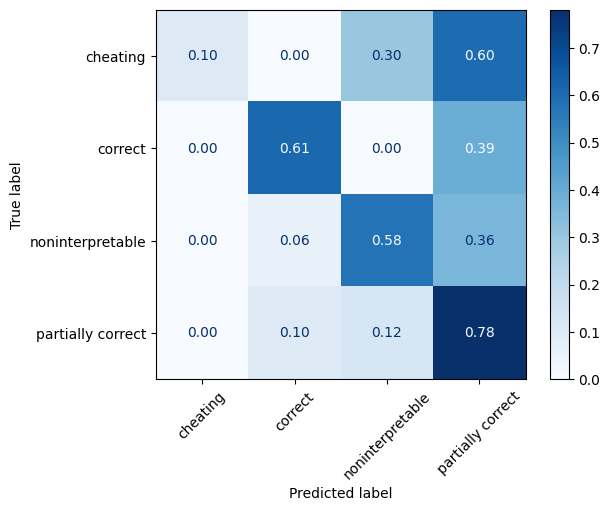

In [10]:
disp_normalized_true = ConfusionMatrixDisplay.from_predictions(
    df['category'].map(lambda x: labels_to_ids[x]), df['category_pred'].map(lambda x: labels_to_ids[x]),
    display_labels=labels_to_ids.keys(),
    cmap='Blues',
    normalize='true',
    values_format=".2f",
    xticks_rotation=45,
)

# Plotting
# fig_norm_true, ax_norm_true = plt.subplots(figsize=(8, 6))
# disp_normalized_true.plot(cmap='Blues', ax=ax_norm_true)
# ax_norm_true.set_title('Normalized Confusion Matrix')
# plt.show()

Report for difficulty 1:
['correct' 'noninterpretable' 'partially correct']
['correct' 'partially correct' 'noninterpretable']
Report for difficulty 2:
['cheating' 'correct' 'noninterpretable' 'partially correct']
['partially correct' 'noninterpretable' 'correct']
Report for difficulty 3:
['cheating' 'correct' 'noninterpretable' 'partially correct']
['partially correct' 'cheating' 'noninterpretable' 'correct']
Report for difficulty 4:
['correct' 'noninterpretable' 'partially correct']
['correct' 'partially correct' 'noninterpretable']
Report for difficulty 5:
['correct' 'noninterpretable' 'partially correct']
['partially correct' 'correct' 'noninterpretable']


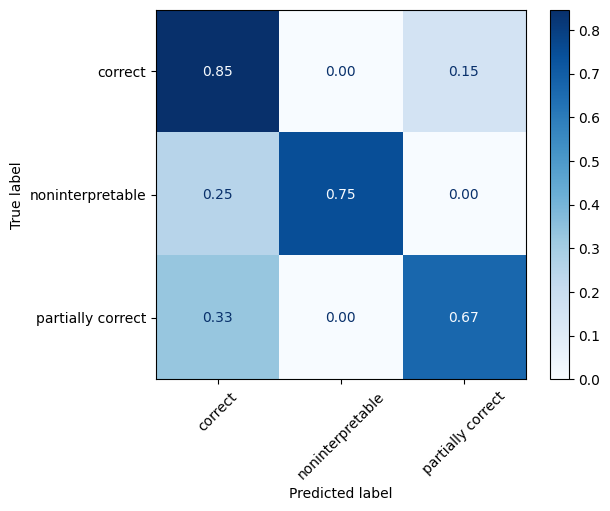

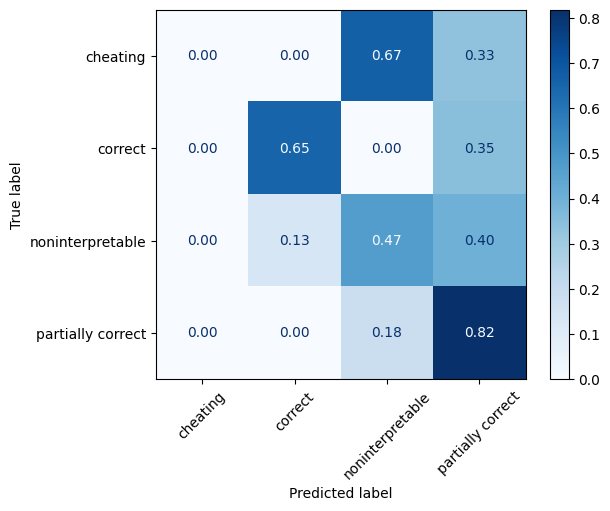

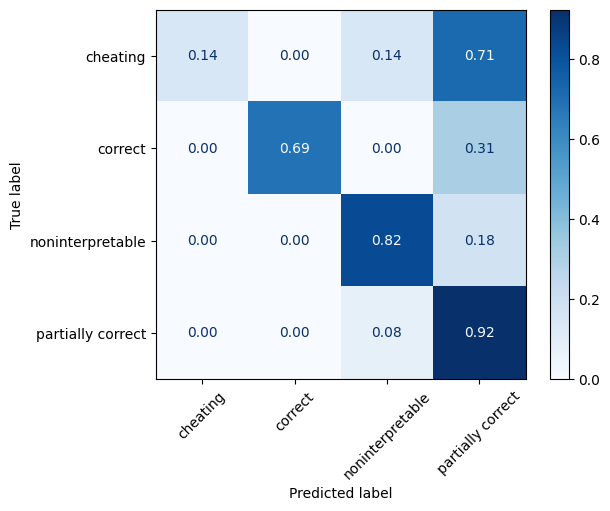

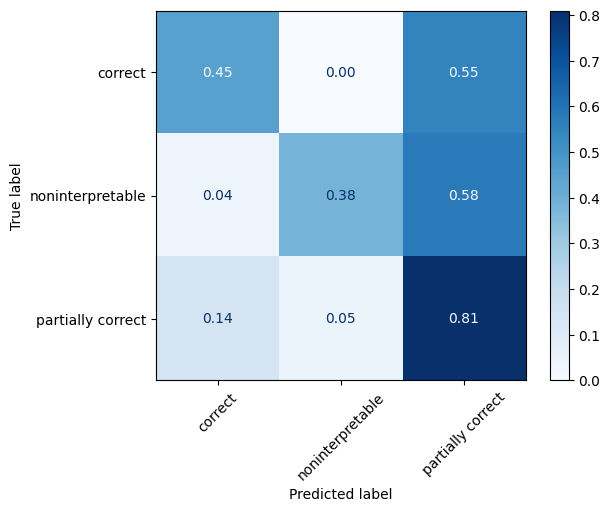

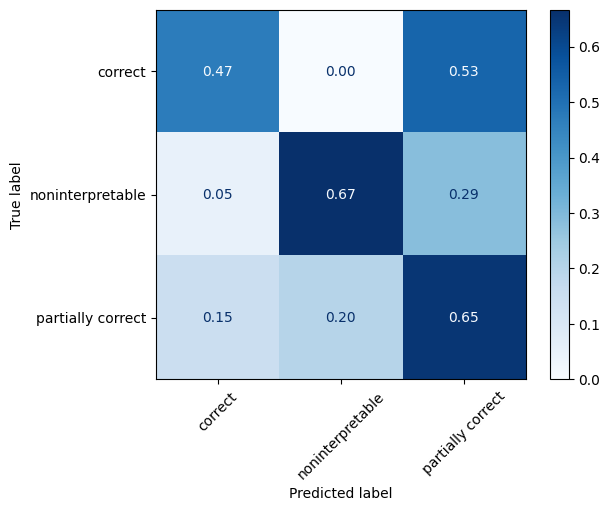

In [11]:
for diff in difficulties:
    print(f"Report for difficulty {diff}:")
    print(df[df['difficulty'] == diff]['category'].unique())
    print(df[df['difficulty'] == diff]['category_pred'].unique())
    disp_normalized_true = ConfusionMatrixDisplay.from_predictions(
        df[df['difficulty'] == diff]['category'].map(lambda x: labels_to_ids[x]), df[df['difficulty'] == diff]['category_pred'].map(lambda x: labels_to_ids[x]),
        display_labels=df[df['difficulty'] == diff]['category'].unique(),
        cmap='Blues',
        normalize='true',
        values_format=".2f",
        xticks_rotation=45,
    )

    # # Plotting
    # fig_norm_true, ax_norm_true = plt.subplots(figsize=(8, 6))
    # disp_normalized_true.plot(cmap='Blues', ax=ax_norm_true)
    # ax_norm_true.set_title('Normalized Confusion Matrix')
    # plt.show()